# Visualize Raw Data

In [19]:
import os
filename = os.path.join(os.path.expanduser('~'), 'DATA','In_Vivo_experiments', 'NDNF-WT-Dec-2022','NWBs',  '2022_12_14-13-27-41.nwb')

In [20]:
# general python modules for scientific analysis
import sys, pathlib, os
import numpy as np

# add the python path:
sys.path.append('../src')
from physion.utils import plot_tools as pt
from physion.analysis.read_NWB import Data, scan_folder_for_NWBfiles

import warnings
warnings.filterwarnings("ignore") # disable the UserWarning from pynwb (arrays are not well oriented)

In [21]:
data = Data(filename,
            verbose=False)
data.build_rawFluo(verbose=False)
data.build_dFoF(verbose=False)

## Showing Field of View

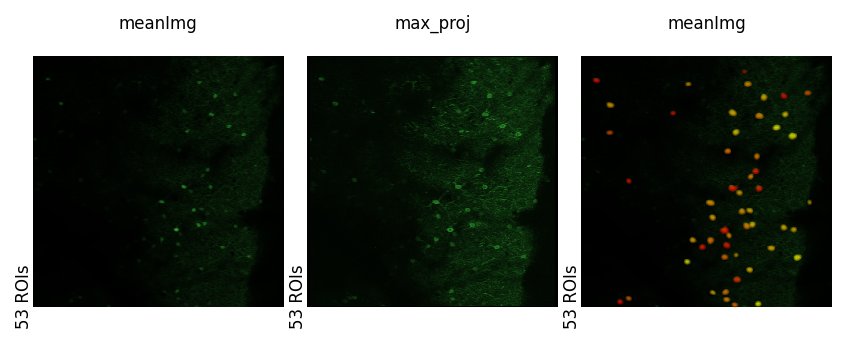

In [22]:
fig, AX = pt.figure(axes=(3,1), figsize=(1.4,3), wspace=0.15)

from physion.dataviz.imaging import show_CaImaging_FOV
#
show_CaImaging_FOV(data, key='meanImg', 
                   cmap=pt.get_linear_colormap('k', 'tab:green'),
                   NL=2, # non-linearity to normalize image
                   ax=AX[0])
show_CaImaging_FOV(data, key='max_proj', 
                   cmap=pt.get_linear_colormap('k', 'tab:green'),
                   NL=2, # non-linearity to normalize image
                   ax=AX[1])
show_CaImaging_FOV(data, key='meanImg', 
                   cmap=pt.get_linear_colormap('k', 'tab:green'),
                   NL=2,
                   roiIndices=range(data.nROIs), 
                   ax=AX[2])

# save on desktop
fig.savefig(os.path.join(os.path.expanduser('~'), 'Desktop','NDNF', 'FOV.png'))

# Show Raw Data

in locomotion  [0.12072556 0.11156767 0.09538089 ... 0.07941157 0.08705051 0.10100976]
len locomotion x 4999
len locomotion y 4999
Indices 1 and 2 of time and sumbsampling Locomotion 1  ,  5000  ,  1
threshold cond [False False False ... False False False]
len threshold cond 4999
len x Facemotion 3448
len y Facemotion 3448
Indices 1 and 2 of time and sumbsampling Facemotion 344  ,  3792  ,  1


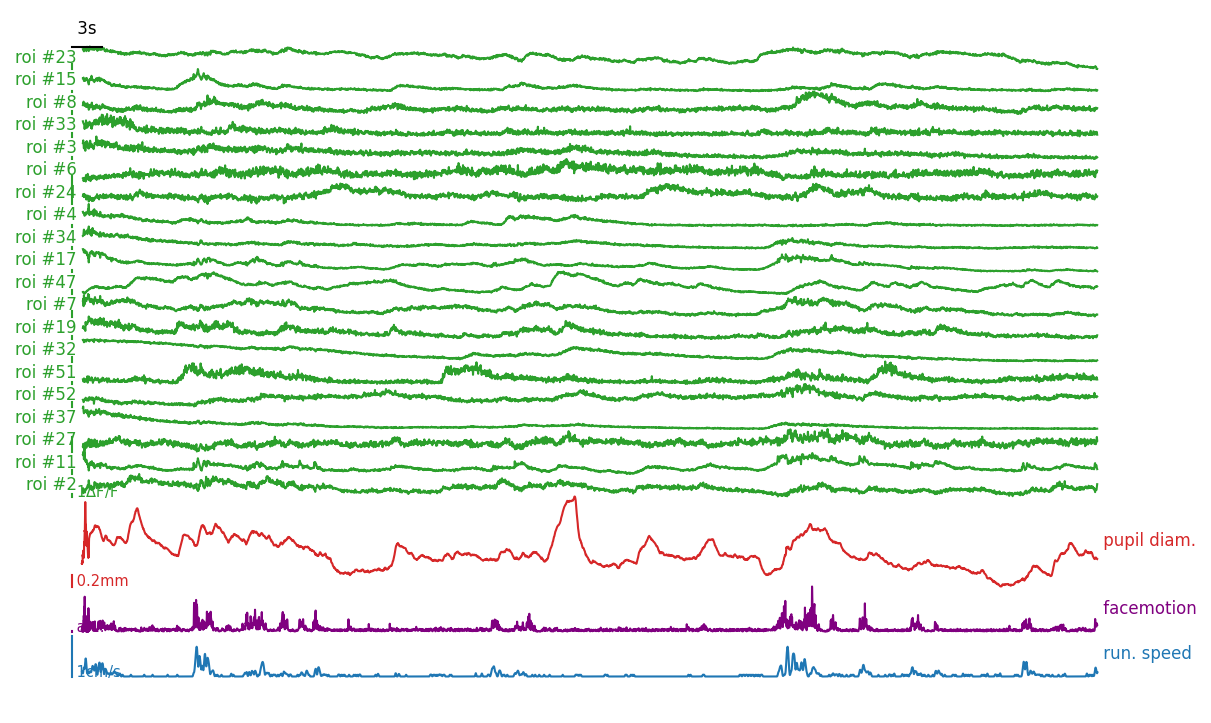

In [18]:
# default plot
from physion.dataviz.raw import plot as plot_raw, find_default_plot_settings
settings = {'Locomotion': {'fig_fraction': 1,
                           'subsampling': 1,
                           'color': '#1f77b4'},
            'FaceMotion': {'fig_fraction': 1,
                           'subsampling': 1,
                           'color': 'purple'},
            'Pupil': {'fig_fraction': 2,
                      'subsampling': 1,
                      'color': '#d62728'},
             'CaImaging': {'fig_fraction': 10,
                           'subsampling': 1,
                           'subquantity': 'dF/F',
                           'roiIndices': np.random.choice(np.arange(data.nROIs), np.min([20,data.nROIs]), replace=False),
                           'color': '#2ca02c'}
           }
fig, _ = plot_raw(data, settings=settings)
fig.savefig(os.path.join(os.path.expanduser('~'), 'Desktop','NDNF', 'Raw_data.png'))

## Full view

{'Locomotion': {'fig_fraction': 1, 'subsampling': 1, 'color': '#1f77b4'}, 'FaceMotion': {'fig_fraction': 1, 'subsampling': 1, 'color': 'purple'}, 'Pupil': {'fig_fraction': 2, 'subsampling': 1, 'color': '#d62728'}, 'CaImaging': {'fig_fraction': 10, 'subsampling': 1, 'subquantity': 'dF/F', 'roiIndices': array([38,  7, 45, 31, 42, 25,  1, 21, 12, 17, 32, 14, 48, 46, 27, 34,  9,
       41, 19, 51]), 'color': '#2ca02c'}}
in locomotion  [0.12072556 0.11156767 0.09538089 ... 0.00300639 0.00120157 0.00121001]
len locomotion x 101146
len locomotion y 101146
Indices 1 and 2 of time and sumbsampling Locomotion 1  ,  101147  ,  1
threshold cond [False False False ... False False False]
len threshold cond 101146
len x Facemotion 61148
len y Facemotion 61148
Indices 1 and 2 of time and sumbsampling Facemotion 344  ,  61492  ,  1


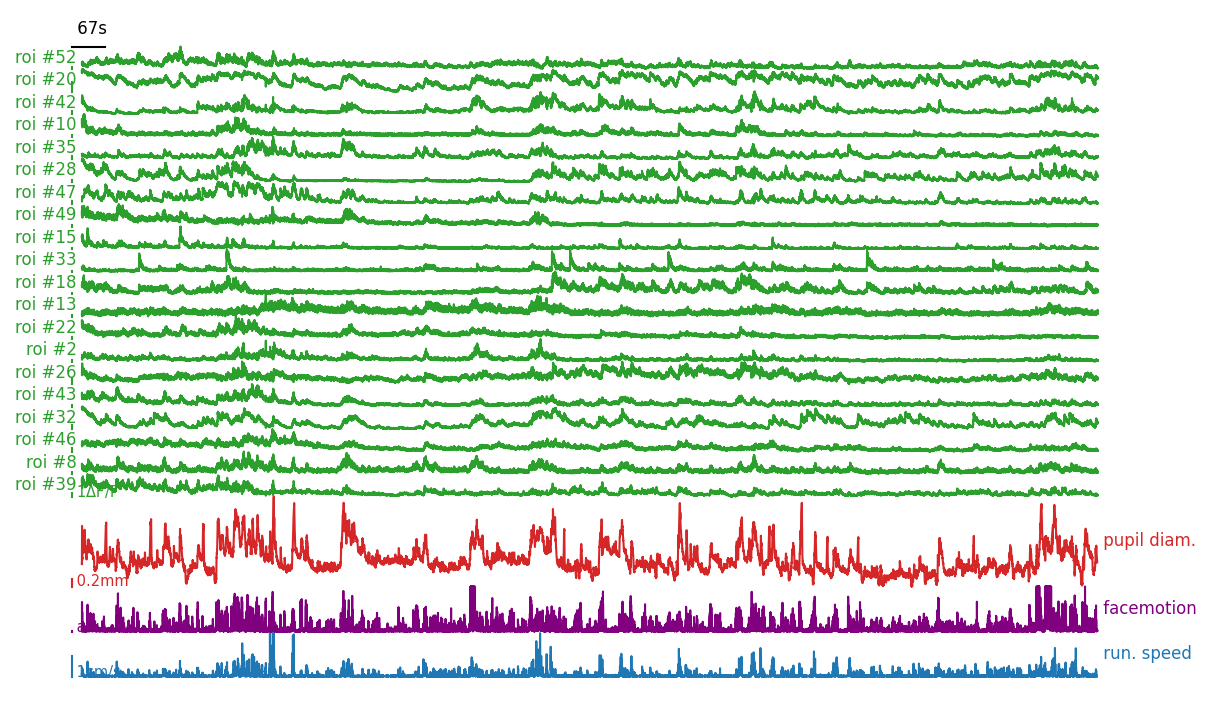

In [15]:

settings = {'Locomotion': {'fig_fraction': 1,
                           'subsampling': 1,
                           'color': '#1f77b4'},
            'FaceMotion': {'fig_fraction': 1,
                           'subsampling': 1,
                           'color': 'purple'},
            'Pupil': {'fig_fraction': 2,
                      'subsampling': 1,
                      'color': '#d62728'},
             'CaImaging': {'fig_fraction': 10,
                           'subsampling': 1,
                           'subquantity': 'dF/F',
                           'roiIndices': np.random.choice(np.arange(data.nROIs), np.min([20,data.nROIs]), replace=False),
                           'color': '#2ca02c'}
           }

print(settings)
fig, _ = plot_raw(data, tlim=[0, data.t_dFoF[-1]], settings=settings)
fig.savefig(os.path.join(os.path.expanduser('~'), 'Desktop', 'NDNF', 'full_view.png'))